# =====================================================
# BAGUS NOTEBOOK 2026
# Text Classification with Modern Embeddings
# Author : Bagustyo
# =====================================================

# Mengapa Notebook Ini Ada?

Pada tahun 2023 kita mengubah text menjadi angka
menggunakan tokenization dan embedding sederhana.

Pada tahun 2026 kita memanfaatkan embedding model
yang sudah memahami makna kalimat.

Target:

Text
↓
Embedding
↓
Classifier
↓
Prediction
↓
API

In [ ]:
!pip install sentence-transformers
!pip install lightgbm
!pip install scikit-learn
!pip install fastapi uvicorn

## Filosofi

Jangan install library karena tutorial menyuruh.

Install karena kita tahu perannya.

sentence-transformers
→ memahami kalimat

lightgbm
→ classifier

fastapi
→ deployment

In [11]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/TYO_NLTK/DATASET_3000/DATASET_JUDUL_BERITA.xlsx")

In [12]:
df = df[['JUDUL','KATEGORI']]
df.head(10)

,JUDUL,KATEGORI
0,Total Aset Keuangan Syariah RI Tembus Rp2.200 ...,EKONOMI
1,VIDEO: Bagaimana Cara Kerja Robot Trading?,EKONOMI
2,5 Dampak Kenaikan Suku Bunga BI yang Bikin Beb...,EKONOMI
3,Heru Mundur dari Kursi Komisaris BTN Sebelum D...,EKONOMI
4,INFOGRAFIS: Efek Berantai Penguatan Dolar AS k...,EKONOMI
5,Rupiah Lunglai ke Rp15.695 per Dolar AS Imbas ...,EKONOMI
6,Moody's Pangkas Outlook Peringkat Utang Inggri...,EKONOMI
7,Suku Bunga The Fed Tekuk Rupiah Berlutut Nyari...,EKONOMI
8,Jasa Raharja Santuni 18 Korban Kebakaran KM Ca...,EKONOMI
9,Rupiah Menguat ke Rp15.563 usai Imbal Hasil Ob...,EKONOMI


In [13]:
df['KATEGORI'].value_counts()

,count
KATEGORI,
EKONOMI,751
KESEHATAN,751
OLAH RAGA,751
POLITIK,751


Sebelum melatih model,
lihat dulu isi data.

Ini seperti dokter memeriksa pasien
sebelum memberikan obat.

In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(
    df["KATEGORI"]
)

Mesin tidak memahami:

ekonomi
olahraga
kesehatan

Mesin memahami:

0
1
2

In [17]:
y

array([0, 0, 0, ..., 3, 3, 3])

In [18]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-small"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Dulu:

Motor rusak

dan

Sepeda motor mengalami kerusakan

dianggap berbeda.

Sekarang embedding modern memahami
bahwa kedua kalimat memiliki makna yang dekat.

In [20]:
X = embedding_model.encode(
    df["JUDUL"].tolist(),
    normalize_embeddings=True
)

Kita lihat hasil embedd nya :D

In [21]:
X[:10]

array([[ 0.06418662, -0.04118706, -0.07100717, ...,  0.06985386,
        -0.02334427,  0.06288428],
       [ 0.07588933, -0.0559621 , -0.12768291, ...,  0.09051291,
         0.04565052,  0.03221725],
       [ 0.06091499, -0.01842349, -0.02703304, ...,  0.07641027,
         0.01919567,  0.0434733 ],
       ...,
       [ 0.05637847, -0.02519671, -0.04417301, ...,  0.06844638,
        -0.00338276,  0.05494887],
       [ 0.05516746, -0.05936793, -0.03169017, ...,  0.05144528,
         0.00565258,  0.05086527],
       [ 0.07000064, -0.02309719, -0.01441067, ...,  0.06986596,
         0.00345289,  0.05493453]], dtype=float32)

Kita Visualiasasi dulu

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [23]:
pca = PCA(n_components=2)

X_2d = pca.fit_transform(X)

Pertanyaan:

Apakah artikel olahraga
berkumpul dengan olahraga?

Apakah artikel ekonomi
berkumpul dengan ekonomi?

Mari lihat.

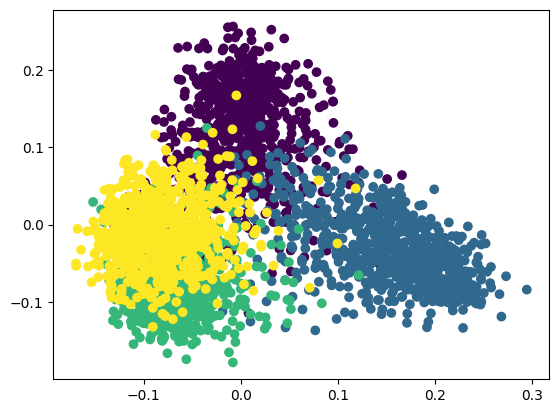

In [27]:
plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=y
)

In [28]:
X_2d = pca.fit_transform(X)

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42
)

Pisahkan data latihan dan ujian.

Jika tidak,
model akan menghafal.

In [32]:
from lightgbm import LGBMClassifier

clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05
)

Mengapa LightGBM?

Karena:

- cepat
- ringan
- akurat
- cocok untuk embedding

In [33]:
clf.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023937 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97920
[LightGBM] [Info] Number of data points in the train set: 2253, number of used features: 384
[LightGBM] [Info] Start training from score -1.386738
[LightGBM] [Info] Start training from score -1.384964
[LightGBM] [Info] Start training from score -1.386738
[LightGBM] [Info] Start training from score -1.386738
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

LGBMClassifier(learning_rate=0.05, n_estimators=300)

Saat ini Mesin sedang belajar.

Bukan belajar bahasa Indoneisa dong

Tetapi belajar pola heheeheh

In [35]:
pred = clf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [36]:
from sklearn.metrics import classification_report

In [39]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       188
           1       0.95      0.96      0.95       187
           2       0.93      0.90      0.91       188
           3       0.88      0.91      0.90       188

    accuracy                           0.92       751
   macro avg       0.92      0.92      0.92       751
weighted avg       0.92      0.92      0.92       751



## Mengapa Tidak Cukup Melihat Accuracy?

Accuracy hanya menjawab satu pertanyaan:

> "Berapa persen prediksi yang benar?"

Misalnya model menghasilkan:

```python
Accuracy = 95%
```

Angka tersebut terlihat sangat bagus, tetapi belum memberi tahu kita:

- kelas mana yang paling sering salah
- apakah model sering melewatkan suatu kategori
- apakah model terlalu sering menebak kategori tertentu

---

### Precision

Precision menjawab pertanyaan:

> "Ketika model mengatakan sebuah berita termasuk kategori tertentu, seberapa sering prediksi itu benar?"

Contoh:

Model memprediksi 120 berita sebagai **POLITIK**.

Dari 120 berita tersebut:

- 80 benar-benar POLITIK ✅
- 40 sebenarnya bukan POLITIK ❌

Maka:

```text
Precision = 80 / 120
          = 66.7%
```

Artinya:

> Dari semua berita yang diprediksi sebagai POLITIK, hanya 66.7% yang benar.

---

### Recall

Recall menjawab pertanyaan:

> "Dari seluruh berita POLITIK yang benar-benar ada, berapa banyak yang berhasil ditemukan model?"

Contoh:

Terdapat 100 berita POLITIK dalam dataset.

Model berhasil menemukan:

- 80 berita POLITIK ✅
- 20 berita POLITIK terlewat ❌

Maka:

```text
Recall = 80 / 100
       = 80%
```

Artinya:

> Model berhasil menemukan 80% berita POLITIK yang sebenarnya ada.

---

### F1 Score

F1 Score merupakan keseimbangan antara Precision dan Recall.

Jika:

- Precision tinggi tetapi Recall rendah
- atau Recall tinggi tetapi Precision rendah

maka nilai F1 akan turun.

F1 cocok digunakan ketika kita ingin melihat kualitas model secara keseluruhan.

---

### Pada Dataset Berita

Misalnya hasil evaluasi:

```text
              precision    recall    f1-score

EKONOMI          0.97       0.95       0.96
KESEHATAN        0.98       0.99       0.98
OLAH RAGA        0.96       0.97       0.96
POLITIK          0.92       0.95       0.93

accuracy                               0.96
```

Dari accuracy saja kita hanya tahu:

```text
Model benar 96%
```

Tetapi dari precision, recall, dan f1-score kita bisa mengetahui bahwa:

- Kategori POLITIK paling sulit diprediksi
- Model sering tertukar antara POLITIK dan kategori lain
- Ada peluang memperbaiki performa khusus pada kategori POLITIK

---

### Kesimpulan

Accuracy memberi tahu:

> "Seberapa sering model benar?"

Precision memberi tahu:

> "Jika model yakin suatu kategori, apakah ia benar?"

Recall memberi tahu:

> "Apakah ada data yang terlewat?"

F1 Score memberi tahu:

> "Seberapa baik keseimbangan antara Precision dan Recall?"

Karena itu, pada proyek NLP modern kita hampir selalu melihat:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

bukan Accuracy saja.

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

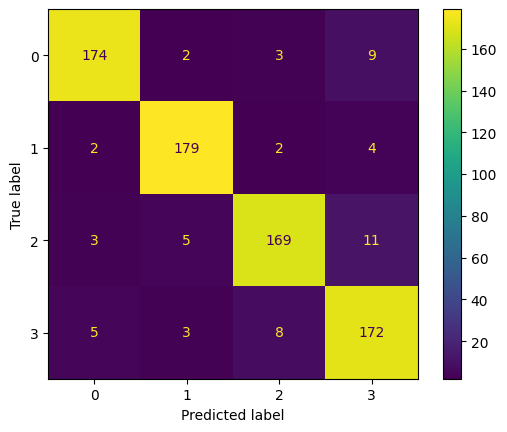

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

Kesalahan model lebih penting
daripada keberhasilan model.

Karena dari situlah kita belajar.

# Pertanyaan Penting

Mengapa model salah?

Apakah label salah?

Apakah artikel ambigu?

Apakah kategori tumpang tindih?

Machine Learning bukan hanya coding.

Machine Learning adalah investigasi.

In [49]:
import joblib

joblib.dump(
    clf,
    "/content/drive/MyDrive/TYO_NLTK/MODEL/2026/classifier.pkl"
)

joblib.dump(
    encoder,
    "/content/drive/MyDrive/TYO_NLTK/MODEL/2026/label_encoder.pkl"
)

['/content/drive/MyDrive/TYO_NLTK/MODEL/2026/label_encoder.pkl']

# ==========================================
# TESTING PREDICTION
# ==========================================

In [47]:


samples = [
    "Bank Indonesia menaikkan suku bunga acuan menjadi 6 persen",
    "Timnas Indonesia berhasil mengalahkan Jepang dengan skor 2-1",
    "Kementerian Kesehatan melaporkan peningkatan kasus DBD",
    "Presiden bertemu dengan pimpinan partai koalisi"
]

for text in samples:

    embedding = embedding_model.encode(
        [text],
        normalize_embeddings=True
    )

    prediction = clf.predict(embedding)

    label = encoder.inverse_transform(
        prediction
    )[0]

    print("=" * 60)
    print(f"Judul : {text}")
    print(f"Prediksi : {label}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Judul : Bank Indonesia menaikkan suku bunga acuan menjadi 6 persen
Prediksi : EKONOMI
Judul : Timnas Indonesia berhasil mengalahkan Jepang dengan skor 2-1
Prediksi : OLAH RAGA
Judul : Kementerian Kesehatan melaporkan peningkatan kasus DBD
Prediksi : KESEHATAN
Judul : Presiden bertemu dengan pimpinan partai koalisi
Prediksi : POLITIK


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# KLO MAU LOAD MODEL

In [51]:
import joblib
from sentence_transformers import SentenceTransformer


clf = joblib.load(
    "/content/drive/MyDrive/TYO_NLTK/MODEL/2026/classifier.pkl"
)

encoder = joblib.load(
    "/content/drive/MyDrive/TYO_NLTK/MODEL/2026/label_encoder.pkl"
)


embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-small"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [67]:
def predict_news(text):

    embedding = embedding_model.encode(
        [text],
        normalize_embeddings=True
    )

    pred = clf.predict(embedding)

    label = encoder.inverse_transform(
        pred
    )[0]

    confidence = clf.predict_proba(
        embedding
    ).max()

    return {
        "label": label,
        "confidence": float(confidence)
    }




In [70]:
predict_news(
    "Bank Indonesia menaikkan suku bunga acuan menjadi 6 persen"

)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'label': 'EKONOMI', 'confidence': 0.9999990879352058}